In [70]:
from pathlib import Path
import sys

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

from scraper.database import get_engine, getData
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [71]:
engine = get_engine()

In [72]:
print(engine)

Engine(mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+17+for+SQL+Server%7D%3BSERVER%3Dlocalhost%3BDATABASE%3DDelhaize%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B)


In [73]:
df_products = getData(engine, query="SELECT * FROM Products")
df_productInfo = getData(engine, query="SELECT * FROM ProductDetails")
df_Category = getData(engine, query="SELECT * FROM Categories")

In [74]:
df_products.columns

Index(['ProductId', 'Name', 'Brand', 'CategoryCode', 'Price', 'Currency',
       'DiscountedPrice', 'PricePerUnitValue', 'PricePerUnitUnit',
       'PackageQuantityValue', 'PackageQuantityUnit', 'PackageQuantityLabel',
       'ImageUrl', 'NutriScore', 'Url', 'InStock', 'ScrapedAt'],
      dtype='str')

In [75]:
df_Category.columns

Index(['CategoryCode', 'CategoryName', 'LastScrapedAt', 'ProductCount',
       'CreatedAt'],
      dtype='str')

In [76]:
print(df_products.shape)
print(df_productInfo.shape)
print(df_Category.shape)

(13580, 17)
(13512, 9)
(19, 5)


**df_products:**
- 13580 verschillende producten (rows) met 17 factoren (columns) 

In [77]:
df = pd.merge(df_products, df_productInfo, on="ProductId")
df = df.merge(df_Category, on='CategoryCode')

In totaal hebben we 13512 producten met 29 verschillende factoren

In [78]:
df.shape

(13512, 29)

er zijn geen enkele waarden compleet leeg

In [79]:
df.value_counts().isna().sum()

np.int64(0)

In [80]:
df.columns

Index(['ProductId', 'Name', 'Brand', 'CategoryCode', 'Price', 'Currency',
       'DiscountedPrice', 'PricePerUnitValue', 'PricePerUnitUnit',
       'PackageQuantityValue', 'PackageQuantityUnit', 'PackageQuantityLabel',
       'ImageUrl', 'NutriScore_x', 'Url', 'InStock', 'ScrapedAt_x',
       'NutriScore_y', 'NutritionPer100', 'Ingredients', 'Description',
       'Allergens', 'OtherInfo', 'NetContent', 'ScrapedAt_y', 'CategoryName',
       'LastScrapedAt', 'ProductCount', 'CreatedAt'],
      dtype='str')

In [81]:
df = df.drop(columns=['NutriScore_y', 'ScrapedAt_y'])

In [82]:
df.rename(columns={
    'NutriScore_x' : "NutriScore",
    'ScrapedAt_x' : 'ScrapedAt'
}, inplace=True)

In [83]:
df.shape

(13512, 27)

In [84]:
df[df['ProductId'] == 'F1996070800283300000']

,ProductId,Name,Brand,CategoryCode,Price,Currency,DiscountedPrice,PricePerUnitValue,PricePerUnitUnit,PackageQuantityValue,...,NutritionPer100,Ingredients,Description,Allergens,OtherInfo,NetContent,CategoryName,LastScrapedAt,ProductCount,CreatedAt
87,F1996070800283300000,Spaghetti,Bertagni,v2CON,3.89,EUR,3.5,7.78,kg,500.0,...,NaN,"Tarwebloem,eieren 30 %, griesmeel van harde ta...",Spaghetti,NaN,NaN,NaN,Snel en smakelijk,2026-05-21 10:21:54,560,2026-05-21 07:54:34


We kunnen zien dat 8301 producten geen nutri score hebben, dit is geen fout maar eerder gewoon producten die geen nutri score hebben

In [85]:
df['NutriScore'].value_counts(dropna=False)

NutriScore
NaN    8301
A      1238
C      1215
D      1127
E       819
B       790
Z        22
Name: count, dtype: int64

In [86]:
df.loc[df["NutriScore"].isna(), "Name"]

9          Smeerkaas | Assortiment | Zwitsers
26                            Tuinkers | Vilt
32                                   Rabarber
35       Druiven | Mix | Zonder pit | Verpakt
36       Druiven | Wit | Zonder pit | Verpakt
                         ...                 
13507                Saus | Samurai | Squeeze
13508                Saus | Tartare | Squeeze
13509             Blik | Rum | Daiquiri | RTD
13510                  Mocktail | Spritz | 0%
13511                Mocktail | Spritz | Blik
Name: Name, Length: 8301, dtype: str

5089 producten hebben zowel nutritionPer100 en NutriScore

In [87]:
df[['NutritionPer100', 'NutriScore']].value_counts().sum()

np.int64(5089)

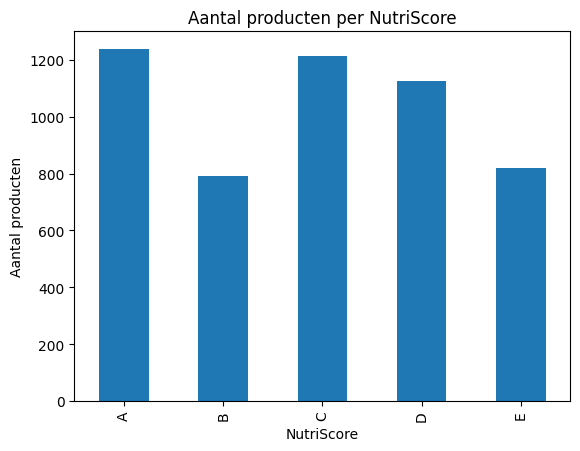

In [88]:
order = ["A", "B", "C", "D", "E"]

df["NutriScore"].value_counts().reindex(order).plot(kind="bar")
plt.title("Aantal producten per NutriScore")
plt.xlabel("NutriScore")
plt.ylabel("Aantal producten")
plt.show()

C:\Users\Luizv\AppData\Local\Temp\ipykernel_37324\952966046.py:14: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  counts["NutriScore"] = pd.Categorical(counts["NutriScore"], categories=order, ordered=True)
C:\Users\Luizv\AppData\Local\Temp\ipykernel_37324\952966046.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x="NutriScore", y="Count", palette="viridis")


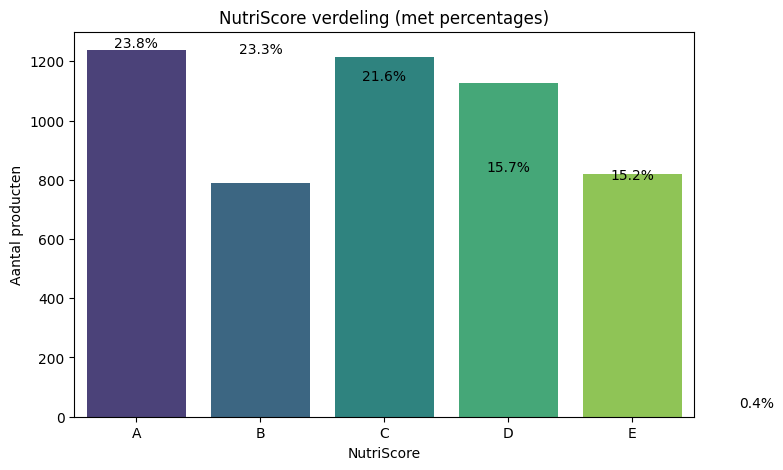

In [90]:
# 1. Data voorbereiden
df_plot = df.copy()
df_plot["NutriScore"] = df_plot["NutriScore"]

counts = df_plot["NutriScore"].value_counts().reset_index()
counts.columns = ["NutriScore", "Count"]

# 2. Percentages toevoegen
total = counts["Count"].sum()
counts["Percentage"] = (counts["Count"] / total * 100).round(1)

# 3. Sorteren (logische volgorde)
order = ["A", "B", "C", "D", "E"]
counts["NutriScore"] = pd.Categorical(counts["NutriScore"], categories=order, ordered=True)
counts = counts.sort_values("NutriScore")

# 4. Plot
plt.figure(figsize=(8,5))
ax = sns.barplot(data=counts, x="NutriScore", y="Count", palette="viridis")

# 5. Labels boven bars
for i, row in counts.iterrows():
    ax.text(
        i,
        row["Count"],
        f'{row["Percentage"]}%',
        ha="center",
        va="bottom"
    )

plt.title("NutriScore verdeling (met percentages)")
plt.xlabel("NutriScore")
plt.ylabel("Aantal producten")
plt.show()